<div style="font-size: 24px; line-height: 1.6;">

# Collider Bias: Selection Changes the Evidence

## A dataset is not just data — it is the result of a selection process

![Collider Bias: Selection Changes the Evidence](../images/collider_bias.png)

</div>

<div style="font-size: 24px; line-height: 1.6;">

## Takeaway

Functions introduced: `pd.read_feather`, `query`, `corr`, `loc`, `iloc`.

**Concept learned: selection can invent or hide relationships.**

</div>

<div style="font-size: 24px; line-height: 1.6;">

### Imports

</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 16
plt.rcParams['figure.figsize'] = (8, 5)

<div style="font-size: 24px; line-height: 1.6;">

## The story

Applicants are selected using ability **and** portfolio. Inside admitted students, the relationship between those two variables can look very different — even reversed — compared to the full applicant pool. The doorway distorts the evidence.

</div>

<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 1. Load the admissions data

Open the file and ask whether it is the full pool or a selected subset. This file is in **Feather** — Apache Arrow's on-disk format, useful for fast interchange between Python and R. `pd.read_feather()` returns a DataFrame just like `read_csv`.

</div>

In [2]:
apps = pd.read_feather("../data/collider_admissions.feather")
apps.head()

,applicant_id,ability,portfolio_score,interview_score,admitted,data_source
0,1,0.908601,0.648566,0.960448,True,admitted_students_file
1,2,0.031086,-1.454628,-1.107673,False,applicant_pool
2,3,0.278576,-0.841460,-1.276033,False,applicant_pool
3,4,0.013985,-0.274854,0.318040,False,applicant_pool
4,5,0.336583,0.779621,0.808507,False,applicant_pool


In [3]:
apps.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   applicant_id     5000 non-null   int64  
 1   ability          5000 non-null   float64
 2   portfolio_score  5000 non-null   float64
 3   interview_score  5000 non-null   float64
 4   admitted         5000 non-null   bool   
 5   data_source      5000 non-null   str    
dtypes: bool(1), float64(3), int64(1), str(1)
memory usage: 276.5 KB


<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 2. Find the selection clue

A source or status column often reveals how rows entered the table.

</div>

In [4]:
apps["data_source"].value_counts()

data_source
applicant_pool            4000
admitted_students_file    1000
Name: count, dtype: int64

In [5]:
apps["admitted"].value_counts()

admitted
False    4000
True     1000
Name: count, dtype: int64

<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 3. Filter with `df.query()`

The whole lesson is comparing admitted students against the full pool, so we split them out with `query()` — the readable way to write a row filter — and check the shapes to confirm the doorway kept only a slice of the applicants.

</div>

In [6]:
admitted = apps.query("admitted == True")
not_admitted = apps.query("admitted == False")
admitted.shape, not_admitted.shape

((1000, 6), (4000, 6))

<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 4. Compare full vs. selected

Now look at the correlation between ability and portfolio in the full pool, then inside the admitted subset.

</div>

In [7]:
apps[["ability", "portfolio_score"]].corr()

,ability,portfolio_score
ability,1.000000,-0.028842
portfolio_score,-0.028842,1.000000


In [8]:
admitted[["ability", "portfolio_score"]].corr()

,ability,portfolio_score
ability,1.000000,-0.352647
portfolio_score,-0.352647,1.000000


<div style="font-size: 24px; line-height: 1.6;">

In the full pool, ability and portfolio are unrelated: knowing one tells you nothing about the other (correlation ≈ 0). Inside the admitted group, a strong **negative** correlation appears (≈ −0.35).

Why? Admission required impressing on *something*. A student who got in with modest ability must have had a strong portfolio; a student with a weak portfolio must have had high ability — otherwise they would not be in the file. The doorway filters out everyone who was low on both, and that missing corner is what manufactures the trade-off.

Here is why it matters: study only the admitted file and you would 'discover' that talented students build worse portfolios — and then hand out coaching advice, change policy, or train a model on a pattern that exists only behind the doorway, not in the world.

</div>

<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 5. Visualize it

Two scatter plots side by side — the full pool next to the admitted subset — make the manufactured pattern visible at a glance.

</div>

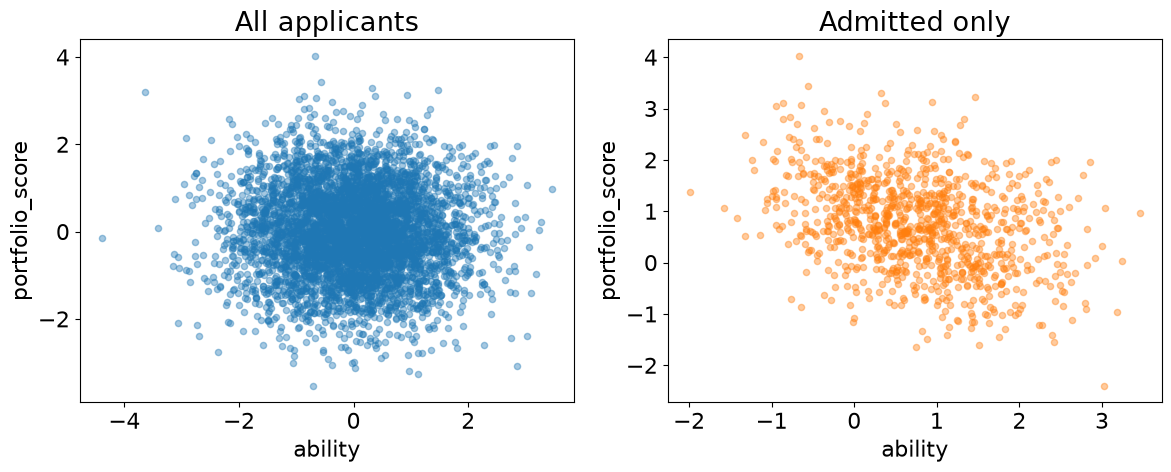

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
apps.plot(kind="scatter", x="ability", y="portfolio_score",
          ax=axes[0], title="All applicants", alpha=0.4)
admitted.plot(kind="scatter", x="ability", y="portfolio_score",
              ax=axes[1], title="Admitted only", alpha=0.4, color="C1")
plt.tight_layout()
plt.show()

<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 6. Compound conditions

Real selection rules often combine multiple conditions.

</div>

In [10]:
apps.query("admitted == True and ability > 0").shape

(798, 6)

In [11]:
apps.query("portfolio_score > 1 or ability > 1").shape

(1461, 6)

<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 7. Column selection with `df.loc[]`

We narrow to just the columns that drive the selection so the table shows only what the analysis compares — `loc` does this by *label*, taking rows by condition and columns by name.

</div>

In [12]:
apps.loc[:, ["ability", "portfolio_score", "admitted"]].head()

,ability,portfolio_score,admitted
0,0.908601,0.648566,True
1,0.031086,-1.454628,False
2,0.278576,-0.841460,False
3,0.013985,-0.274854,False
4,0.336583,0.779621,False


<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 8. Rows and columns together with `loc`

`loc` accepts a row condition and a column list in one call — filter and select in a single step, no chaining needed.

</div>

In [13]:
apps.loc[apps["admitted"] == True, ["ability", "portfolio_score"]].head()

,ability,portfolio_score
0,0.908601,0.648566
7,0.666573,1.315237
11,0.083981,0.482635
26,-0.103420,1.281231
29,0.947650,-0.362191


<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 9. Position selection with `df.iloc[]`

When you just want a quick peek at the first few rows and columns without naming any of them, `iloc` grabs them by position — a fast way to confirm the table matches what the label-based `loc` returned above.

</div>

In [14]:
apps.iloc[:5, :4]

,applicant_id,ability,portfolio_score,interview_score
0,1,0.908601,0.648566,0.960448
1,2,0.031086,-1.454628,-1.107673
2,3,0.278576,-0.841460,-1.276033
3,4,0.013985,-0.274854,0.318040
4,5,0.336583,0.779621,0.808507


<div style="font-size: 24px; line-height: 1.6;">

## Why this matters to a data scientist

Almost every real dataset went through a doorway before it reached you: hospital records contain the people sick enough to come in, support tickets contain the customers annoyed enough to write, loan-default data contains only the applicants who were approved. The selection is invisible in the table — the rows that did not make it leave no trace.

For AI this is a training-data problem. A model trained on approved loans has never seen the applicants the old policy rejected, so it inherits that policy's blind spots — and it can learn manufactured trade-offs exactly like the ability–portfolio one above.

</div>

<div style="font-size: 24px; line-height: 1.6;">

## What to do about it

Three concrete steps, in order:

1. **Name the doorway.** Before you trust any relationship, ask what had to happen for a row to exist, and look for a column that records it — here `data_source` and `admitted` do exactly that. If no such column exists, ask whoever produced the data how the rows were collected. A dataset with *no visible* selection is the one to worry about most, because the doorway is still there — you just cannot see it.

2. **Measure on the full population, not the survivors.** This file still contains the entire applicant pool, so compute the ability–portfolio relationship on *that* (`corr` ≈ 0), not inside the admitted subset (`corr` ≈ −0.35). The rule: never filter down to the selected group before measuring a relationship between the variables that drove the selection — that filter is what manufactures the pattern. For a model, train on the pre-selection rows so it sees the applicants the old policy rejected.

3. **If the rejected rows are genuinely gone, scope the claim.** When all you have is the selected file, you cannot generalize past it. Say so out loud — 'among admitted students…' — instead of implying the pattern holds for everyone, and flag that a model built on it will reproduce the original selection policy, including whoever it used to reject.

</div>